In [2]:
import pandas as pd
import numpy as np

# 1. DEFINE FILENAMES
# Ensure these files are in your current working directory (or Colab folder)
filenames = {
    "btc": "Bitcoin Research - Bitcoin (BTC-USD).csv",
    "sp500": "Bitcoin Research - S&P 500 (^GSPC).csv",
    "fomc": "Bitcoin Research - FOMC.csv",
    "cpi": "Bitcoin Research - CPI.csv",
    "etf": "Bitcoin Research - ETF Flow.csv"
}

print("✅ Starting CSV Data Load...")

# 2. LOAD FILES INTO DATAFRAMES
btc_df = pd.read_csv(filenames["btc"])
sp500_df = pd.read_csv(filenames["sp500"])
fomc_df = pd.read_csv(filenames["fomc"])
cpi_df = pd.read_csv(filenames["cpi"])
etf_df = pd.read_csv(filenames["etf"])

# 3. DATA CLEANING (Numeric & Robust Date Conversion)

# Date Conversion with Error Handling
btc_df['Date'] = pd.to_datetime(btc_df['Date'], errors='coerce')
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'], errors='coerce')
fomc_df['FOMC Meeting Date'] = pd.to_datetime(fomc_df['FOMC Meeting Date'], errors='coerce')
cpi_df['CPI Release Date'] = pd.to_datetime(cpi_df['CPI Release Date'], errors='coerce')
etf_df['Date'] = pd.to_datetime(etf_df['Date'], errors='coerce')

# Drop any rows where the Date failed to convert (like "Total" summary rows)
btc_df = btc_df.dropna(subset=['Date'])
sp500_df = sp500_df.dropna(subset=['Date'])
etf_df = etf_df.dropna(subset=['Date'])

# Force Numbers (handles dashes/commas/blanks/currency symbols)
def clean_numeric(df, column):
    # Ensure column is treated as string before replacement
    temp_col = df[column].astype(str).str.replace(',', '').str.replace('$', '').str.replace('-', '')
    return pd.to_numeric(temp_col, errors='coerce').fillna(0)

btc_df['Close'] = clean_numeric(btc_df, 'Close')
sp500_df['Close'] = clean_numeric(sp500_df, 'Close')
etf_df['Total'] = clean_numeric(etf_df, 'Total')

print("✅ Success: Files loaded and cleaned.")

# 4. MASTER MERGE
# Aligning 24/7 BTC with 5-day TradFi
btc_sub = btc_df[['Date', 'Close']].rename(columns={'Close': 'BTC_Close'})
spx_sub = sp500_df[['Date', 'Close']].rename(columns={'Close': 'SPX_Close'})
etf_sub = etf_df[['Date', 'Total']].rename(columns={'Total': 'ETF_Net_Flow'})

master_df = pd.merge(btc_sub, spx_sub, on='Date', how='left')
master_df = pd.merge(master_df, etf_sub, on='Date', how='left')
master_df = master_df.sort_values('Date').reset_index(drop=True)

# 5. MACRO LOGIC & RETURNS
master_df['Day_Type'] = np.where(master_df['SPX_Close'].isna(), 'Weekend/Holiday', 'Weekday')

# Combine shock dates
shock_dates = pd.concat([fomc_df['FOMC Meeting Date'], cpi_df['CPI Release Date']]).dt.normalize().unique()
master_df['Macro_Shock'] = master_df['Date'].dt.normalize().isin(shock_dates).astype(int)

# Log returns & Volatility
master_df['BTC_Log_Ret'] = np.log(master_df['BTC_Close'] / master_df['BTC_Close'].shift(1))
master_df['BTC_Volatility'] = master_df['BTC_Log_Ret'].abs()

# 6. FILTER FOR 'INSTITUTIONAL ERA' (Jan 11, 2024 onwards)
analysis_df = master_df[(master_df['Day_Type'] == 'Weekday') &
                        (master_df['Date'] >= '2024-01-11')].copy().dropna(subset=['BTC_Log_Ret'])

# 7. OUTPUT RESULTS
print("\n" + "="*30)
print("IEEE RESEARCH DATA SUMMARY")
print("="*30)
shock_vol = analysis_df[analysis_df['Macro_Shock'] == 1]['BTC_Volatility'].mean()
normal_vol = analysis_df[analysis_df['Macro_Shock'] == 0]['BTC_Volatility'].mean()

print(f"Trading Days Analyzed: {len(analysis_df)}")
print(f"Shock Day Volatility: {shock_vol:.5f}")
print(f"Normal Day Volatility: {normal_vol:.5f}")
print(f"Response Factor: {shock_vol/normal_vol:.2f}x")

analysis_df.to_csv('Master_Research_Data.csv', index=False)
print("\nMaster_Research_Data.csv has been saved.")

✅ Starting CSV Data Load...
✅ Success: Files loaded and cleaned.

IEEE RESEARCH DATA SUMMARY
Trading Days Analyzed: 563
Shock Day Volatility: 0.02263
Normal Day Volatility: 0.02102
Response Factor: 1.08x

Master_Research_Data.csv has been saved.


In [3]:
# --- STEP 2.5: FEATURE RE-SYNC ---
# 1. Calculate the S&P 500 Log Returns on the master timeline
master_df['SPX_Log_Ret'] = np.log(master_df['SPX_Close'] / master_df['SPX_Close'].shift(1))

# 2. Re-create the analysis_df to include the new column
# We drop rows where any of our key variables are missing to ensure the math works
analysis_df = master_df[(master_df['Day_Type'] == 'Weekday') &
                        (master_df['Date'] >= '2024-01-11')].copy()

# Drop rows with NaN in the metrics we need for the heatmap/regression
analysis_df = analysis_df.dropna(subset=['BTC_Log_Ret', 'SPX_Log_Ret', 'ETF_Net_Flow'])

print("✅ Analysis Dataframe Updated.")
print(f"Columns now available: {analysis_df.columns.tolist()}")

✅ Analysis Dataframe Updated.
Columns now available: ['Date', 'BTC_Close', 'SPX_Close', 'ETF_Net_Flow', 'Day_Type', 'Macro_Shock', 'BTC_Log_Ret', 'BTC_Volatility', 'SPX_Log_Ret']


In [4]:
# 10. SORT AND DISPLAY THE MASTER DATA TABLE
# Sort by Date descending so the latest 2026 data is at the top
analysis_df = analysis_df.sort_values('Date', ascending=False)

print("\n--- MASTER DATA TABLE PREVIEW (Top 10 Rows - Latest First) ---")
# Using head(10) to show the most recent 10 trading days
display(analysis_df.head(10))

# OPTIONAL: Summary stats for your paper's "Data Description" section
print("\n--- COLUMN SUMMARY STATISTICS ---")
display(analysis_df.describe())


--- MASTER DATA TABLE PREVIEW (Top 10 Rows - Latest First) ---


,Date,BTC_Close,SPX_Close,ETF_Net_Flow,Day_Type,Macro_Shock,BTC_Log_Ret,BTC_Volatility,SPX_Log_Ret
829,2026-04-09,71767.83,6824.66,358.1,Weekday,0,0.009020,0.009020,0.006151
828,2026-04-08,71123.36,6782.81,93.9,Weekday,1,-0.011426,0.011426,0.024772
827,2026-04-07,71940.70,6616.85,159.1,Weekday,0,0.043769,0.043769,0.000759
822,2026-04-02,66888.57,6582.69,9.0,Weekday,0,-0.017634,0.017634,0.001120
821,2026-04-01,68078.55,6575.32,173.7,Weekday,0,-0.002271,0.002271,0.007143
820,2026-03-31,68233.31,6528.52,117.5,Weekday,0,0.022856,0.022856,0.028715
816,2026-03-27,66338.38,6368.85,225.5,Weekday,0,-0.036313,0.036313,-0.016863
815,2026-03-26,68791.63,6477.16,171.3,Weekday,0,-0.035953,0.035953,-0.017559
814,2026-03-25,71309.88,6591.90,7.8,Weekday,0,0.011169,0.011169,0.005405
813,2026-03-24,70517.86,6556.37,74.5,Weekday,0,-0.005614,0.005614,-0.003750



--- COLUMN SUMMARY STATISTICS ---


,Date,BTC_Close,SPX_Close,ETF_Net_Flow,Macro_Shock,BTC_Log_Ret,BTC_Volatility,SPX_Log_Ret
count,435,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000
mean,2025-02-22 16:13:14.482758656,83204.499149,5947.656184,268.442529,0.082759,0.000009,0.020852,0.000521
min,2024-01-11 00:00:00,39845.550000,4739.210000,0.300000,0.000000,-0.152334,0.000020,-0.061609
25%,2024-08-01 12:00:00,65634.310000,5458.000000,86.050000,0.000000,-0.016143,0.007871,-0.003814
50%,2025-02-27 00:00:00,84128.660000,5916.980000,194.400000,0.000000,-0.000822,0.015234,0.000751
75%,2025-09-16 12:00:00,101583.235000,6530.280000,391.500000,0.000000,0.013817,0.029074,0.005716
max,2026-04-09 00:00:00,123354.870000,6978.600000,1373.800000,1.000000,0.118003,0.152334,0.090895
std,NaN,21285.205112,618.607849,246.387437,0.275834,0.028349,0.019181,0.010283


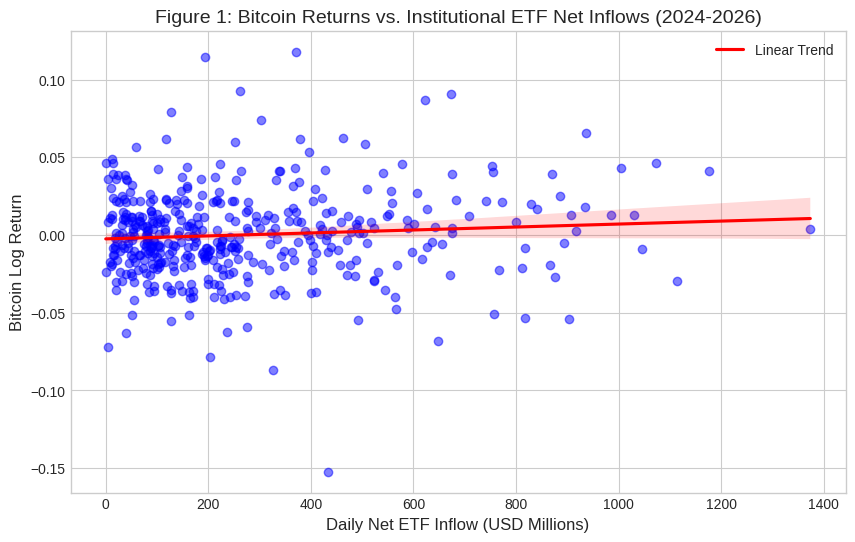

Correlation Coefficient (r) between ETF Flows and BTC Returns: 0.0829


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set the aesthetic for IEEE
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# Create Scatter Plot
sns.regplot(x='ETF_Net_Flow', y='BTC_Log_Ret', data=analysis_df,
            scatter_kws={'alpha':0.5, 'color':'blue'},
            line_kws={'color':'red', 'label':'Linear Trend'})

plt.title('Figure 1: Bitcoin Returns vs. Institutional ETF Net Inflows (2024-2026)', fontsize=14)
plt.xlabel('Daily Net ETF Inflow (USD Millions)', fontsize=12)
plt.ylabel('Bitcoin Log Return', fontsize=12)
plt.legend()
plt.show()

# Calculate Correlation Coefficient (r)
correlation = analysis_df['ETF_Net_Flow'].corr(analysis_df['BTC_Log_Ret'])
print(f"Correlation Coefficient (r) between ETF Flows and BTC Returns: {correlation:.4f}")

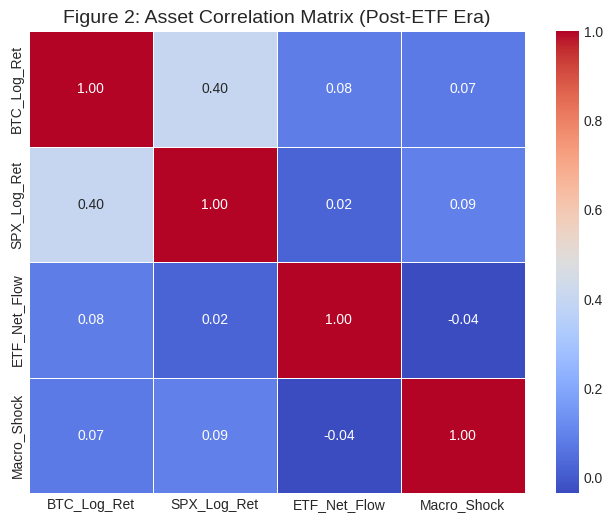

In [6]:
# Calculate the Correlation Matrix
corr_matrix = analysis_df[['BTC_Log_Ret', 'SPX_Log_Ret', 'ETF_Net_Flow', 'Macro_Shock']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Figure 2: Asset Correlation Matrix (Post-ETF Era)', fontsize=14)
plt.show()

In [7]:
import statsmodels.api as sm

# Define X (Independent Variables) and Y (Dependent Variable)
X = analysis_df[['SPX_Log_Ret', 'ETF_Net_Flow', 'Macro_Shock']]
X = sm.add_constant(X) # Adds the intercept (alpha)
Y = analysis_df['BTC_Log_Ret']

# Applying Robust Standard Errors (HC1) to handle Heteroskedasticity
model = sm.OLS(Y, X).fit(cov_type='HC1')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            BTC_Log_Ret   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     13.70
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.50e-08
Time:                        17:38:03   Log-Likelihood:                 973.28
No. Observations:                 435   AIC:                            -1939.
Df Residuals:                     431   BIC:                            -1922.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0032      0.002     -1.878   